In [ ]:
import os
print(os.listdir())

['.config', 'StudentsPerformance.csv', 'sample_data']


Saving StudentsPerformance.csv to StudentsPerformance (1).csv
Uploaded files:
['.config', 'StudentsPerformance.csv', 'StudentsPerformance (1).csv', 'sample_data']

First 5 Rows
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78

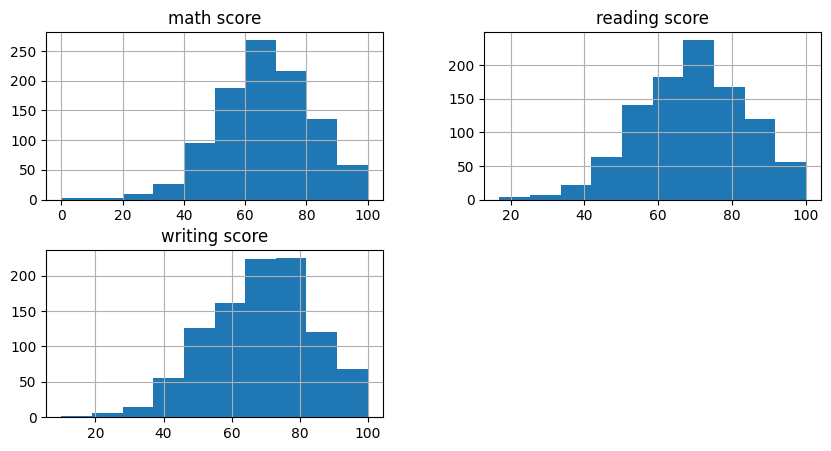

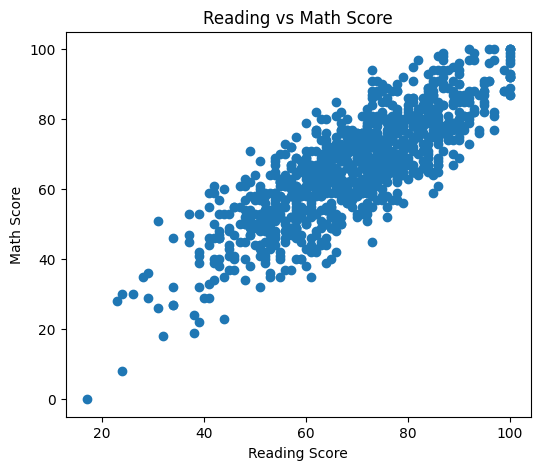


Model Accuracy: 0.5642605403184358

Predicted Math Score: 81.16071428571426


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

import os

print("Uploaded files:")
print(os.listdir())

file_name = "StudentsPerformance.csv"

df = pd.read_csv("/content/StudentsPerformance.csv")

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())


df["average_score"] = (
    df["math score"]
    + df["reading score"]
    + df["writing score"]
) / 3

print("\nAverage Score Added")
print(df.head())


top_students = df.sort_values(
    by="average_score",
    ascending=False
)

print("\nTop 10 Students")
print(top_students.head(10))


gender_avg = df.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean()

print("\nGender-wise Average Scores")
print(gender_avg)


correlation = df[
    ["math score", "reading score", "writing score"]
].corr()

print("\nCorrelation")
print(correlation)

df[
    ["math score", "reading score", "writing score"]
].hist(figsize=(10,5))

plt.show()


plt.figure(figsize=(6,5))

plt.scatter(
    df["reading score"],
    df["math score"]
)

plt.xlabel("Reading Score")

plt.ylabel("Math Score")

plt.title("Reading vs Math Score")

plt.show()


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[
    ["reading score", "writing score"]
]

y = df["math score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    random_state=42
)

model.fit(X_train, y_train)

score = model.score(
    X_test,
    y_test
)

print("\nModel Accuracy:", score)

prediction = model.predict([[80, 85]])

print("\nPredicted Math Score:", prediction[0])

First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Shape of dataset:
(1000, 8)

Columns:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course

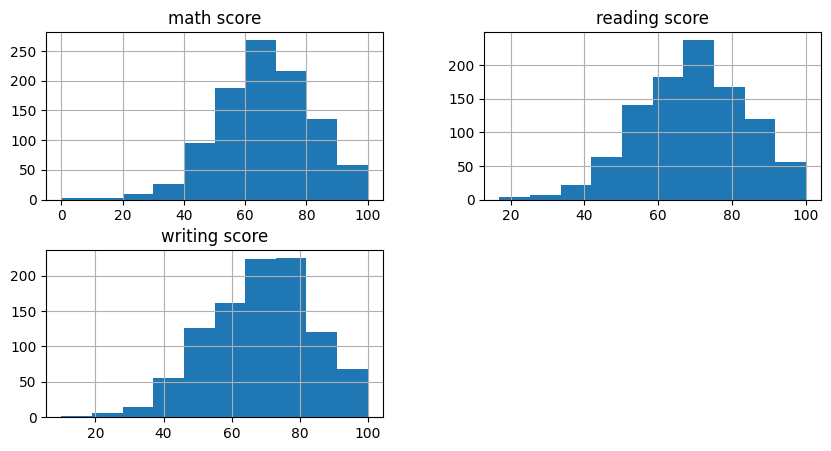

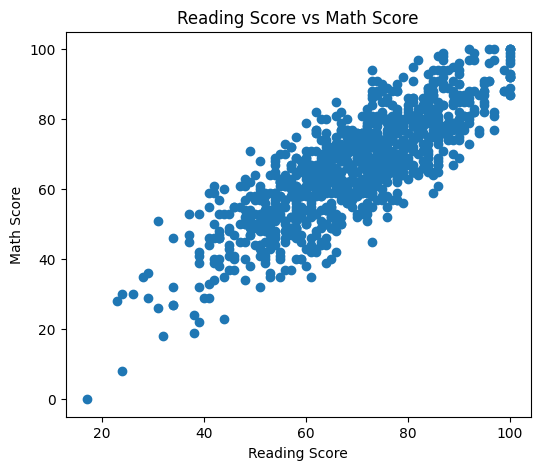


Correlation Matrix
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000

Number of High Performers:
198

Analysis Completed Successfully.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("StudentsPerformance.csv")


print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())


df["Average Score"] = (
    df["math score"]
    + df["reading score"]
    + df["writing score"]
) / 3

print("\nAverage Score Added")

print(
    df[
        [
            "math score",
            "reading score",
            "writing score",
            "Average Score"
        ]
    ].head()
)


top_students = df.sort_values(
    by="Average Score",
    ascending=False
)

print("\nTop 10 Students")

print(
    top_students[
        [
            "gender",
            "Average Score"
        ]
    ].head(10)
)



gender_avg = df.groupby("gender")[
    [
        "math score",
        "reading score",
        "writing score"
    ]
].mean()

print("\nGender-wise Average Scores")

print(gender_avg)

# ------------------------------
# Histograms
# ------------------------------

df[
    [
        "math score",
        "reading score",
        "writing score"
    ]
].hist(figsize=(10,5))

plt.show()


plt.figure(figsize=(6,5))

plt.scatter(
    df["reading score"],
    df["math score"]
)

plt.xlabel("Reading Score")

plt.ylabel("Math Score")

plt.title("Reading Score vs Math Score")

plt.show()

# ------------------------------
# Correlation
# ------------------------------

correlation = df[
    [
        "math score",
        "reading score",
        "writing score"
    ]
].corr()

print("\nCorrelation Matrix")

print(correlation)



high_performers = df[
    df["Average Score"] >= 80
]

print("\nNumber of High Performers:")

print(len(high_performers))


df.to_csv(
    "student_performance_output.csv",
    index=False
)

print("\nAnalysis Completed Successfully.")